# Process Performance Map

Visualizes model prediction performance overlaid on a process map.

- **Start node**: How many cases start with each activity
- **Node color**: Overall accuracy when predicting from this activity
- **Edge color**: Accuracy for this specific transition (green = high, red = low)
- **Edge label**: correct/total predictions

In [1]:
# Setup
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

import torch
from src.interpretability.config.domestic_declarations_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability.process_performance_map import ProcessPerformanceMap

print(f"Dataset: {CONFIG.dataset_name}")

Dataset: DomesticDeclarations


In [2]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by ADMINISTRATION': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('s

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Loaded 15471 samples
Available cases: 2100


In [3]:
# Collect predictions
ppm = ProcessPerformanceMap(
    model=model,
    test_dataset=test_dataset,
    eval_helper=eval_helper,
    activity_key=CONFIG.concept_name,
    device=device
)

ppm.collect_predictions(show_progress=True)

Collected 9169 predictions
Found 27 unique transitions


In [4]:
# Create activity name mapping
label_dict = ppm.get_activity_label_dict()
activity_name_map = {str(idx): name for name, idx in label_dict.items()}

print("Activity mapping:")
for idx_str in sorted(activity_name_map.keys(), key=lambda x: int(x) if x.isdigit() else 0):
    print(f"  {idx_str}: {activity_name_map[idx_str]}")

Activity mapping:
  1: Declaration APPROVED by ADMINISTRATION
  2: Declaration APPROVED by BUDGET OWNER
  3: Declaration APPROVED by PRE_APPROVER
  4: Declaration FINAL_APPROVED by SUPERVISOR
  5: Declaration FOR_APPROVAL by ADMINISTRATION
  6: Declaration FOR_APPROVAL by SUPERVISOR
  7: Declaration REJECTED by ADMINISTRATION
  8: Declaration REJECTED by BUDGET OWNER
  9: Declaration REJECTED by EMPLOYEE
  10: Declaration REJECTED by MISSING
  11: Declaration REJECTED by PRE_APPROVER
  12: Declaration REJECTED by SUPERVISOR
  13: Declaration SAVED by EMPLOYEE
  14: Declaration SUBMITTED by EMPLOYEE
  15: EOS
  16: Payment Handled
  17: Request Payment


## Process Map

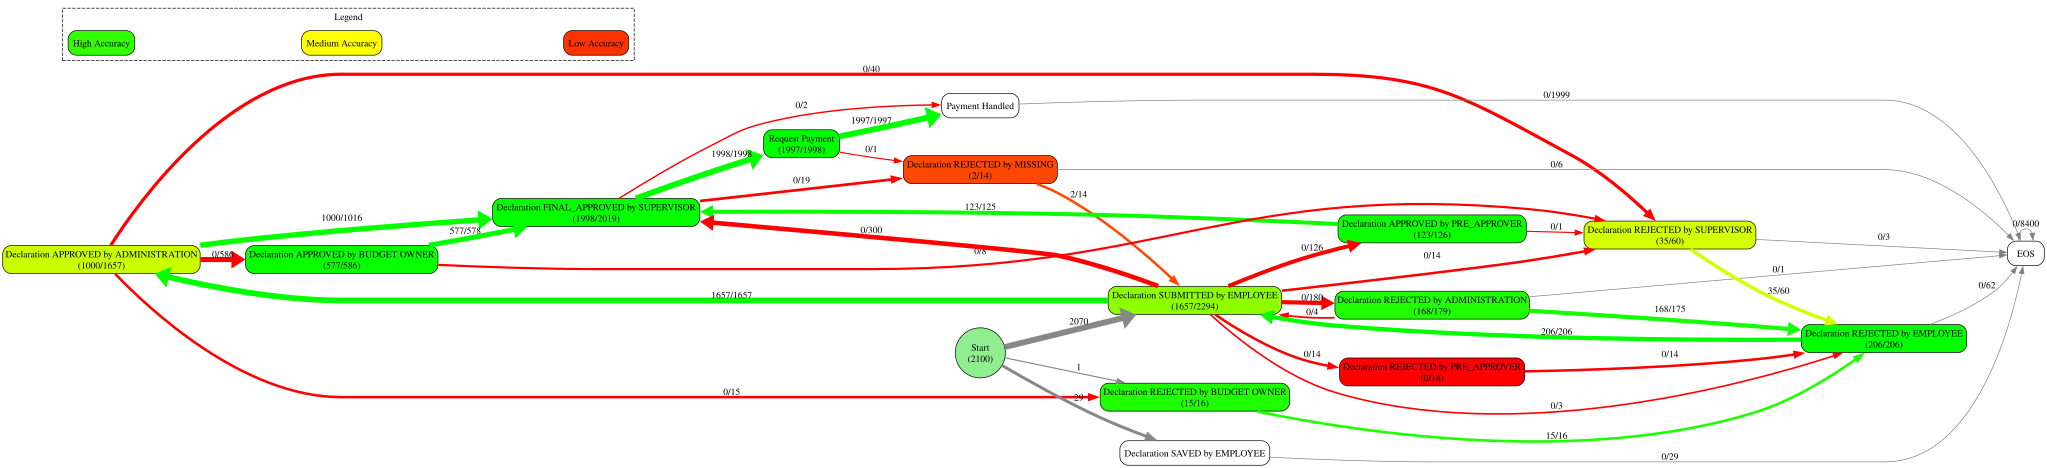

In [5]:
# Generate process map
dot = ppm.visualize(
    min_edge_count=1,
    show_counts=True,
    activity_name_map=activity_name_map,
    show_start_node=True
)
dot

## Interactive Explorer

In [6]:
# Interactive exploration
explorer = ppm.create_interactive_explorer(activity_name_map=activity_name_map)
explorer.show()